In [ ]:
import pandas as pd


nom_fichier = Path("/home/onyxia/work/data/data_indian_ocean.feather")

df = pd.read_feather(nom_fichier)

df.columns
#


Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)'],
      dtype='object')

In [2]:
df.head

<bound method NDFrame.head of               imo       mmsi          name   latitude  longitude  \
0         7361922  538003805  GOLAR FREEZE  25.031168  55.067681   
1         7361922  538003805  GOLAR FREEZE  25.031168  55.067828   
2         7361922  538003805  GOLAR FREEZE  25.031168  55.067757   
3         7361922  538003805  GOLAR FREEZE  25.031168  55.067830   
4         7361922  538003805  GOLAR FREEZE  25.031168  55.067745   
...           ...        ...           ...        ...        ...   
13736053  9982689  636024852     AL QASSAR  11.464126  70.506199   
13736054  9982689  636024852     AL QASSAR  11.642743  70.351657   
13736055  9982689  636024852     AL QASSAR  11.817274  70.185509   
13736056  9982689  636024852     AL QASSAR  11.992234  70.012758   
13736057  9982689  636024852     AL QASSAR  12.187894  69.863625   

                           timestamp        sog         cog  \
0         2015-01-01T01:46:03.000000   0.000000  248.059574   
1         2015-01-01T02:46:

In [3]:
df['sog']

0            0.000000
1            0.000000
2            0.000000
3            0.000000
4            0.000000
              ...    
13736053    13.833333
13736054    14.159574
13736055    14.500000
13736056    14.582353
13736057    14.500000
Name: sog, Length: 13736058, dtype: float64

In [3]:
import numpy as np
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(["voyage number", "timestamp"])

df["sog_ms"] = df["sog"] * 0.514444  # noeuds → m/s
df["delta_v"] = df.groupby("voyage number")["sog_ms"].diff()
df["delta_t"] = df.groupby("voyage number")["timestamp"].diff().dt.total_seconds()

df["acceleration_ms2"] = df["delta_v"] / df["delta_t"]

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["acceleration_ms2"])

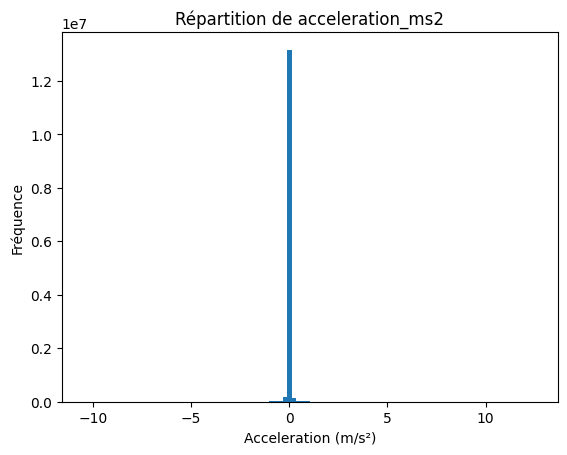

In [4]:
import matplotlib.pyplot as plt

# Supprimer les valeurs NaN et infinies
acc = df["acceleration_ms2"].replace([float("inf"), -float("inf")], None).dropna()

plt.figure()
plt.hist(acc, bins=100)
plt.xlabel("Acceleration (m/s²)")
plt.ylabel("Fréquence")
plt.title("Répartition de acceleration_ms2")
plt.show()

In [ ]:
df["acceleration_ms2"].describe()

count    1.370182e+07
mean    -1.518991e-03
std      2.942156e-01
min     -1.043085e+01
25%     -7.679987e-04
50%      0.000000e+00
75%      7.638256e-04
max      1.252667e+01
Name: acceleration_ms2, dtype: float64

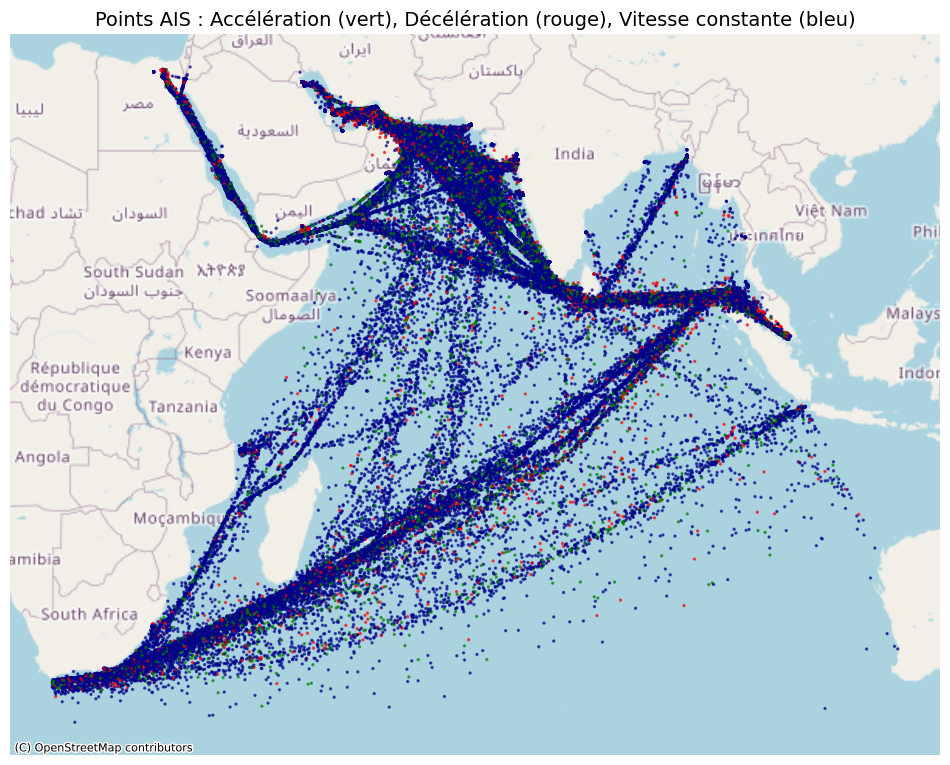

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from shapely.geometry import Point

# 1️⃣ Nettoyage et filtrage
df_clean = df.dropna(subset=["acceleration_ms2", "latitude", "longitude"])
df_clean = df_clean[np.isfinite(df_clean["acceleration_ms2"])]
df_clean = df_clean[np.abs(df_clean["acceleration_ms2"]) < 3]  # filtre pour éviter les valeurs aberrantes

# 2️⃣ Échantillon de 100 000 points
df_sample = df_clean.sample(n=min(100000, len(df_clean)), random_state=42)

# 3️⃣ Création de la colonne géométrique
geometry = [Point(xy) for xy in zip(df_sample["longitude"], df_sample["latitude"])]
gdf = gpd.GeoDataFrame(df_sample, geometry=geometry, crs="EPSG:4326")

# 4️⃣ Reprojection en Web Mercator pour contextily
gdf = gdf.to_crs(epsg=3857)

# 5️⃣ Définir les couleurs selon accélération
def acc_color(a):
    if a > 0.01:
        return "green"
    elif a < -0.01:
        return "red"
    else:
        return "darkblue"

gdf["color"] = gdf["acceleration_ms2"].apply(acc_color)

# 6️⃣ Plot avec fond de carte
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, markersize=2, color=gdf["color"], alpha=0.6)

# Ajouter le fond de carte contextily (OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Retirer axes
ax.set_axis_off()
plt.title("Points AIS : Accélération (vert), Décélération (rouge), Vitesse constante (bleu)", fontsize=14)
plt.show()

# Création d'indicatrices

In [5]:
df["is_acceleration"] = (df["acceleration_ms2"] > 0.02).astype(int)
df["is_deceleration"] = (df["acceleration_ms2"] < -0.02).astype(int)

# Clusters

In [6]:
# 📦 Import des librairies
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import hdbscan

# -------------------------------------------------
# 1️⃣ Nettoyage et filtrage
# -------------------------------------------------
# Supprime NaN et inf
df_sample = df[df["acceleration_ms2"].abs() > 0.02].sample(n=100_000, random_state=42)

df_sample = df_sample.replace([np.inf, -np.inf], np.nan)
df_sample = df_sample.dropna(subset=["acceleration_ms2", "latitude", "longitude"])

# Filtre par seuil significatif (ici |a| > 0.02 m/s²)
threshold = 0.01
df_cluster = df_sample[df_sample["acceleration_ms2"] < -threshold].copy()

# -------------------------------------------------
# 2️⃣ Créer un GeoDataFrame
# -------------------------------------------------
geometry = [Point(xy) for xy in zip(df_cluster["longitude"], df_cluster["latitude"])]
gdf = gpd.GeoDataFrame(df_cluster, geometry=geometry, crs="EPSG:4326")

# Reprojection en EPSG:3857 pour distances en mètres
gdf = gdf.to_crs(epsg=3857)

# -------------------------------------------------
# 3️⃣ Préparer les coordonnées pour HDBSCAN
# -------------------------------------------------
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

# -------------------------------------------------
# 4️⃣ Appliquer HDBSCAN
# -------------------------------------------------
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,   # taille minimale du cluster
    min_samples=15,        # robustesse
    metric="euclidean"     # distances métriques après reprojection
)

gdf["cluster"] = clusterer.fit_predict(coords)
gdf["cluster_strength"] = clusterer.probabilities_  # optionnel : force d’appartenance

# -------------------------------------------------
# 5️⃣ Option : transférer la colonne cluster dans le df d’origine
# -------------------------------------------------
# Pour garder tous les points, y compris ceux filtrés
df["cluster"] = np.nan
df.loc[gdf.index, "cluster"] = gdf["cluster"]

# ✅ Maintenant df contient une colonne 'cluster'
print(df["cluster"].value_counts(dropna=False))

cluster
 NaN      13652387
-1.0         25048
 165.0         574
 50.0          565
 195.0         537
            ...   
 418.0          10
 205.0          10
 305.0          10
 273.0          10
 26.0           10
Name: count, Length: 494, dtype: int64


/tmp/ipykernel_51268/725267341.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20', n_clusters)  # 20 couleurs max


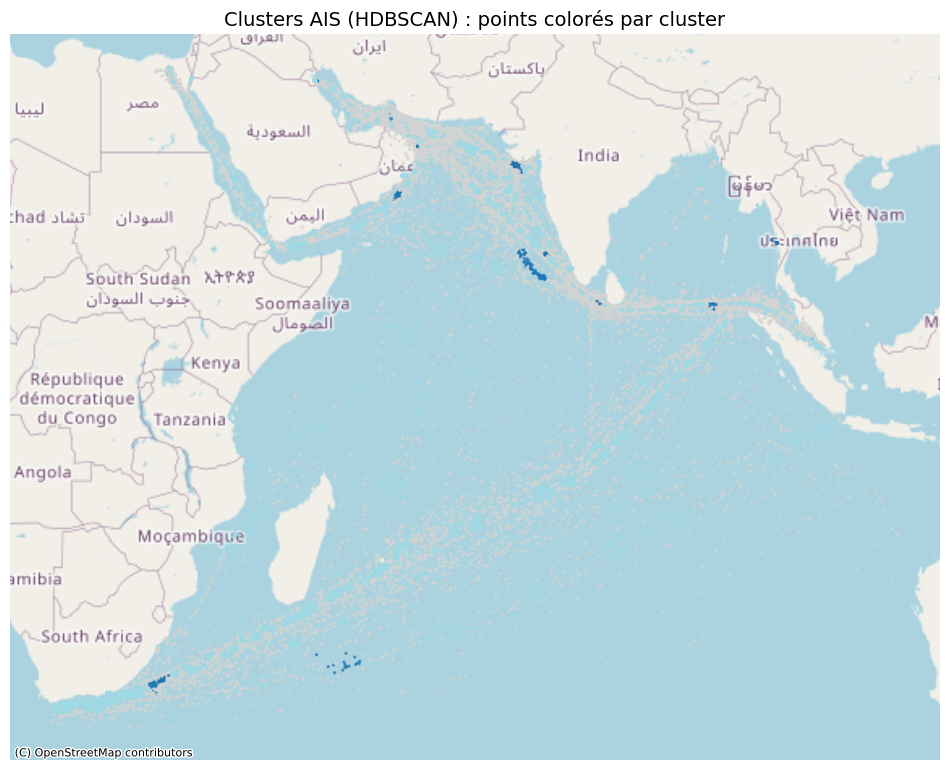

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
import numpy as np

# -------------------------------
# 1️⃣ Préparer le GeoDataFrame
# -------------------------------
# Assurez-vous d'avoir les colonnes latitude/longitude et cluster
df_plot = df.dropna(subset=["cluster", "latitude", "longitude"]).copy()

geometry = [Point(xy) for xy in zip(df_plot["longitude"], df_plot["latitude"])]
gdf = gpd.GeoDataFrame(df_plot, geometry=geometry, crs="EPSG:4326")

# Reprojection Web Mercator pour fond de carte
gdf = gdf.to_crs(epsg=3857)

# -------------------------------
# 2️⃣ Choisir les couleurs pour les clusters
# -------------------------------
# Points bruit (-1) en gris
import matplotlib
n_clusters = len(gdf["cluster"].unique())
cmap = matplotlib.cm.get_cmap('tab20', n_clusters)  # 20 couleurs max

# Création d'une colonne couleur
def cluster_color(cluster_id):
    if cluster_id == -1:
        return "lightgrey"  # bruit
    else:
        # Retourne une couleur de la colormap
        return matplotlib.colors.to_hex(cmap(cluster_id % 20))

gdf["color"] = gdf["cluster"].apply(cluster_color)

# -------------------------------
# 3️⃣ Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, color=gdf["color"], markersize=2, alpha=0.6)

# Ajouter fond de carte OSM
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Retirer axes
ax.set_axis_off()
plt.title("Clusters AIS (HDBSCAN) : points colorés par cluster", fontsize=14)
plt.show()

# Statistiques descriptives

## Distance à la côte

In [7]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

def ajouter_distance_a_la_cote(df, coast_shapefile):
    """
    Ajoute une colonne 'distance_a_la_cote' à un dataframe AIS.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes 'latitude' et 'longitude'
    coast_shapefile : str
        Chemin vers le shapefile des côtes (Natural Earth ou GSHHS)
    
    Returns
    -------
    pandas.DataFrame
        DataFrame original avec une colonne 'distance_a_la_cote' en mètres
    """
    
    # 1️⃣ Charger les côtes et fusionner pour accélérer
    coast = gpd.read_file(coast_shapefile).to_crs(epsg=3857)
    coast_union = coast.unary_union
    
    # 2️⃣ Créer un GeoDataFrame pour tous les points
    geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
    gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326")
    
    # 3️⃣ Reprojection métrique pour distances en mètres
    gdf = gdf.to_crs(epsg=3857)
    
    # 4️⃣ Calculer la distance minimale à la côte
    gdf["distance_a_la_cote"] = gdf.geometry.apply(lambda x: x.distance(coast_union))
    
    # 5️⃣ Retourner le dataframe avec la nouvelle colonne
    return pd.DataFrame(gdf.drop(columns="geometry"))  # retirer colonne geometry si non nécessaire

In [12]:
df = ajouter_distance_a_la_cote(
    df,
    "ne_10m_coastline.shp"
)

/tmp/ipykernel_80302/2276527221.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  coast_union = coast.unary_union


KeyboardInterrupt: 

# AJOUTER LES COTES

In [ ]:
import matplotlib.pyplot as plt

def scatter_plot(df, x_col, y_col, color_col=None, size_col=None,
                 title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7):
    """
    Affiche un scatter plot pour deux variables.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes à tracer
    x_col : str
        Nom de la colonne pour l'axe X
    y_col : str
        Nom de la colonne pour l'axe Y
    color_col : str, optional
        Colonne pour la couleur des points
    size_col : str, optional
        Colonne pour la taille des points
    title : str, optional
        Titre du graphique
    xlabel : str, optional
        Label axe X
    ylabel : str, optional
        Label axe Y
    figsize : tuple, optional
        Taille de la figure (largeur, hauteur)
    alpha : float, optional
        Transparence des points (0 à 1)
    """

    plt.figure(figsize=figsize)

    if color_col and size_col:
        sc = plt.scatter(df[x_col], df[y_col], c=df[color_col], s=df[size_col],
                         alpha=alpha, cmap='viridis')
    elif color_col:
        sc = plt.scatter(df[x_col], df[y_col], c=df[color_col], alpha=alpha, cmap='viridis')
        plt.colorbar(sc, label=color_col)
    elif size_col:
        sc = plt.scatter(df[x_col], df[y_col], s=df[size_col], alpha=alpha)
    else:
        sc = plt.scatter(df[x_col], df[y_col], alpha=alpha)

    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    if title:
        plt.title(title)

    plt.grid(True)
    plt.show()

In [14]:
df.columns

Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)', 'sog_ms', 'delta_v',
       'delta_t', 'acceleration_ms2', 'is_acceleration', 'is_deceleration',
       'cluster'],
      dtype='object')

In [9]:
Vargood=['wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)']

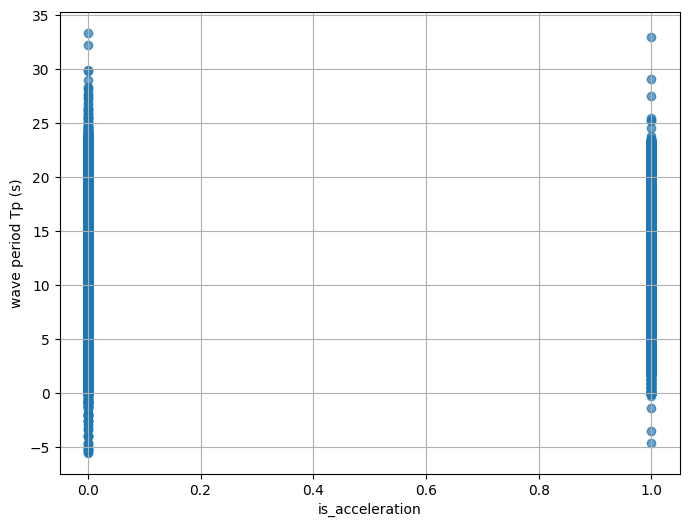

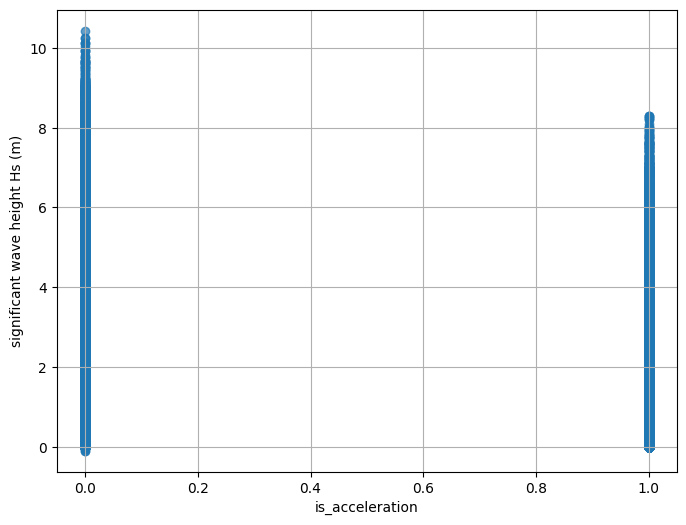

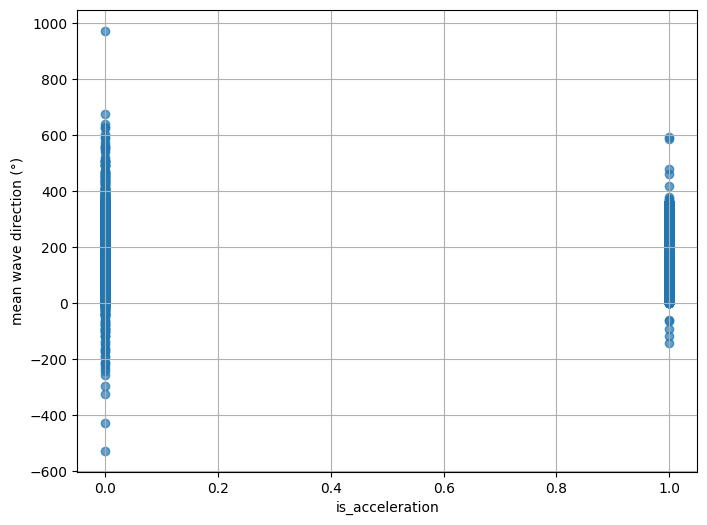

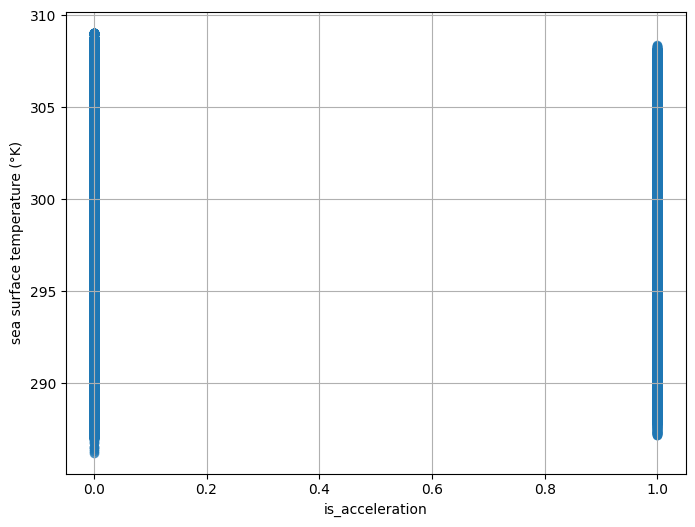

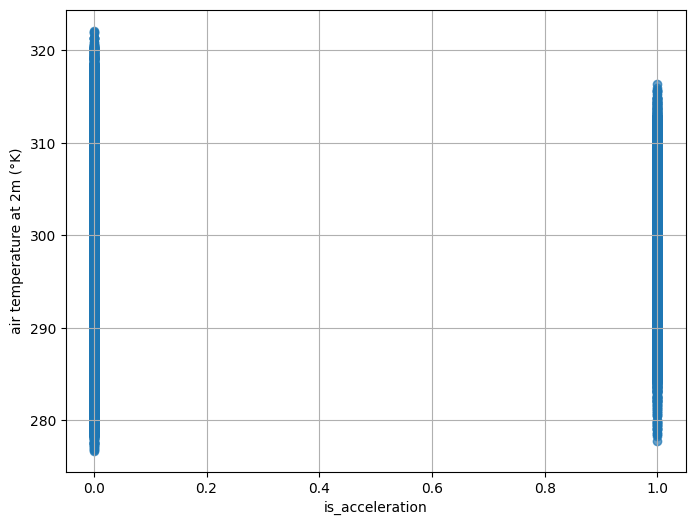

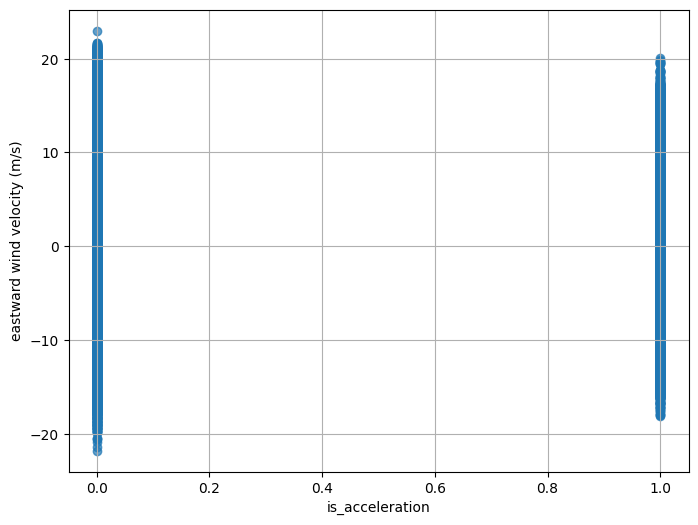

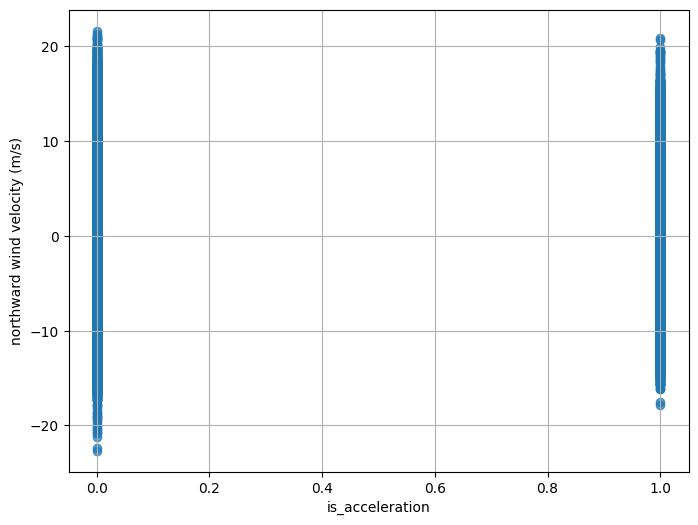

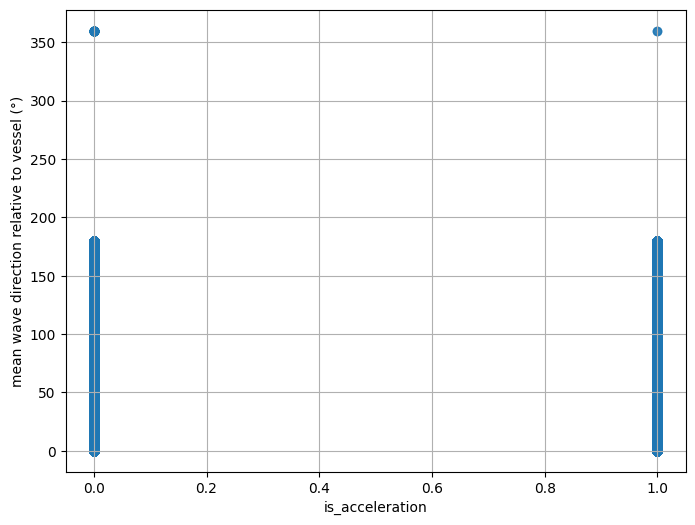

In [34]:
"""for second_variable in Vargood:
    scatter_plot(df, x_col='is_acceleration', y_col=second_variable,
                 color_col=None, size_col=None,
                 title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7)"""

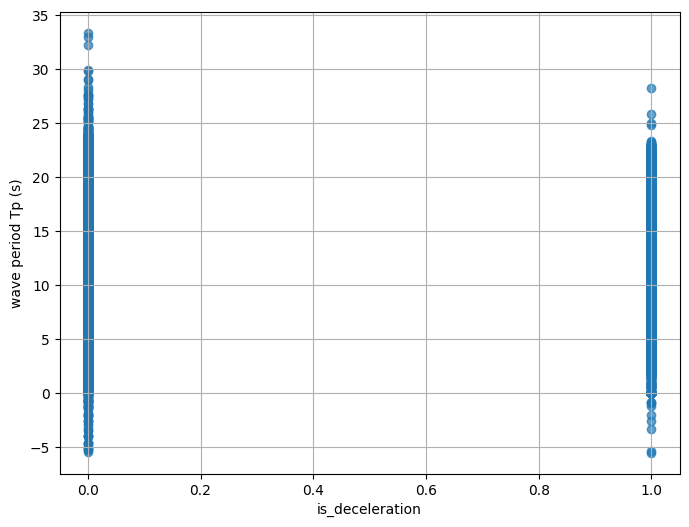

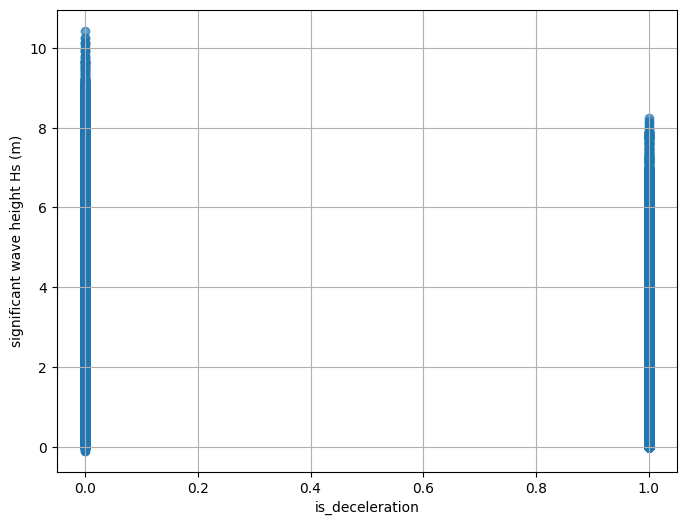

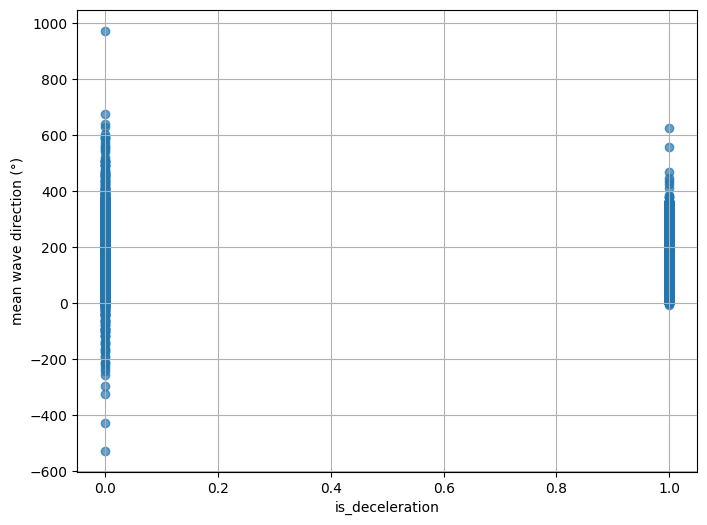

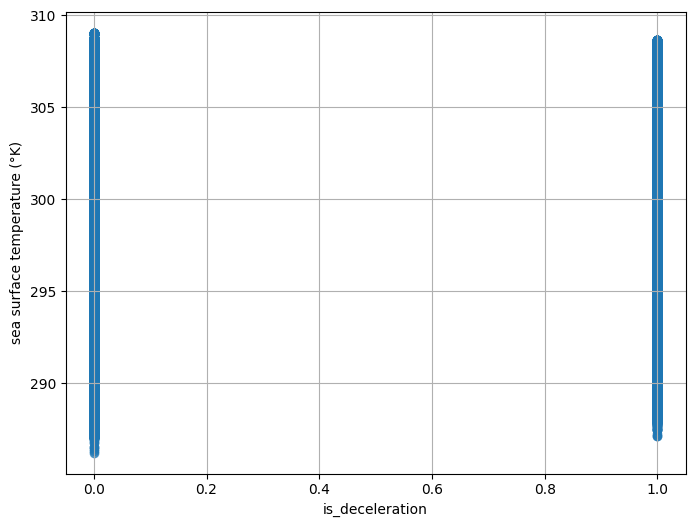

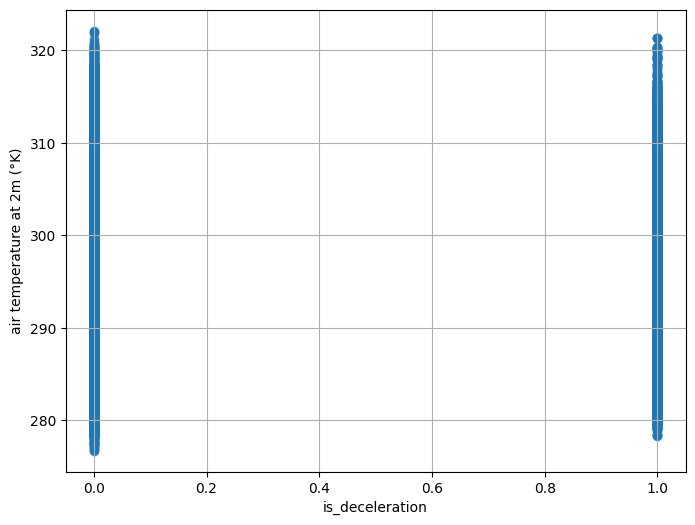

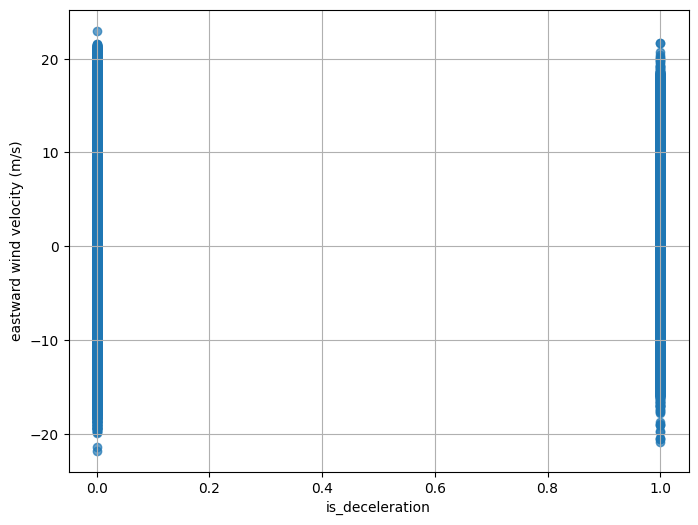

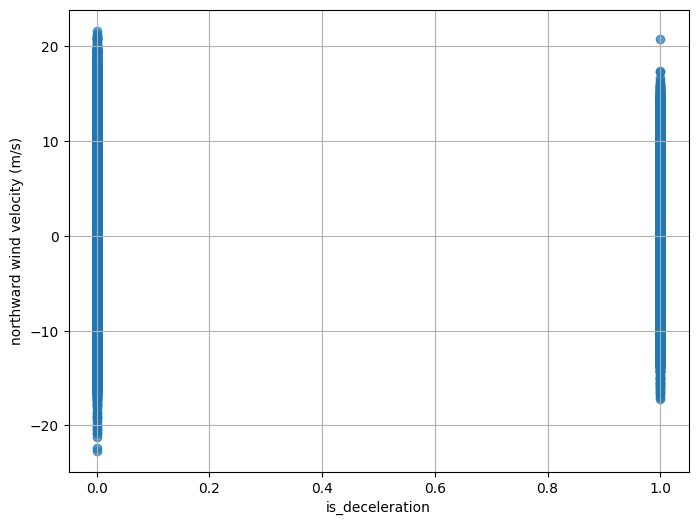

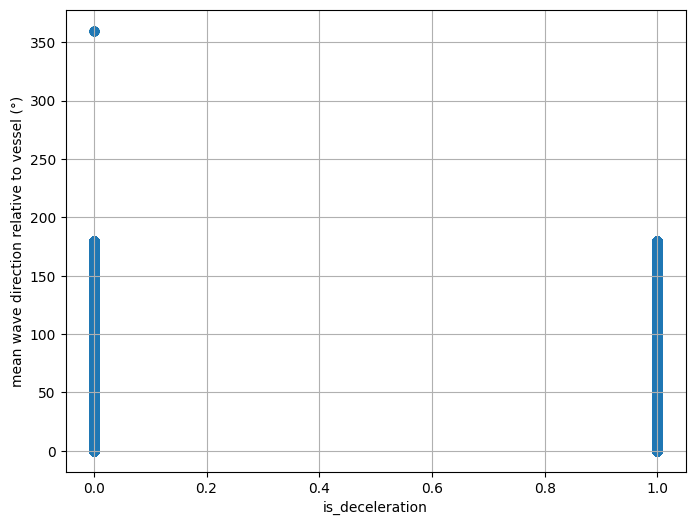

In [35]:
for second_variable in Vargood:
    scatter_plot(df, x_col='is_deceleration', y_col=second_variable,
                 color_col=None, size_col=None,
                 title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7)

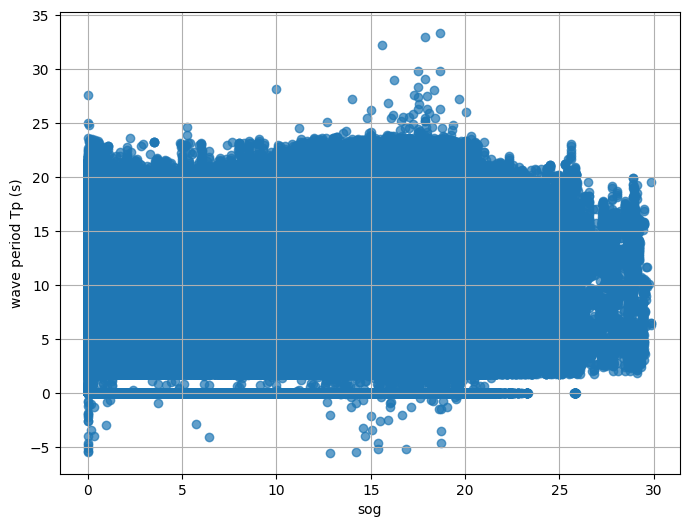

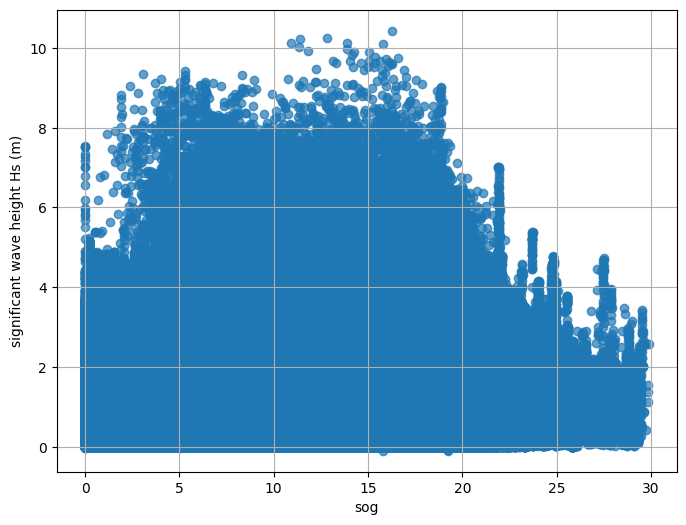

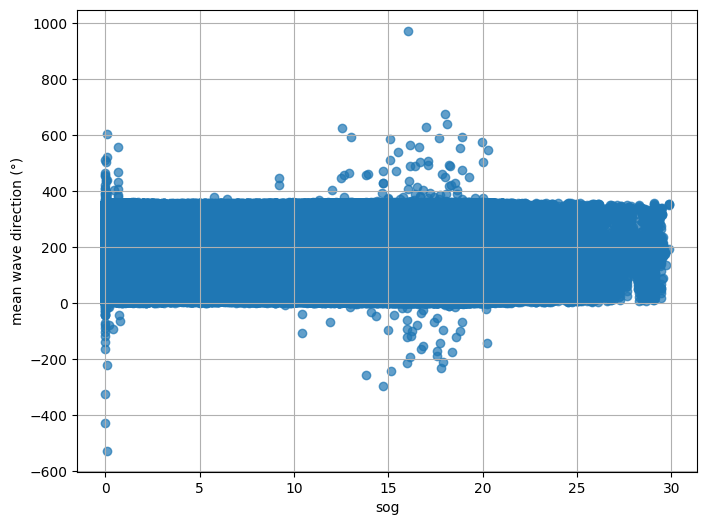

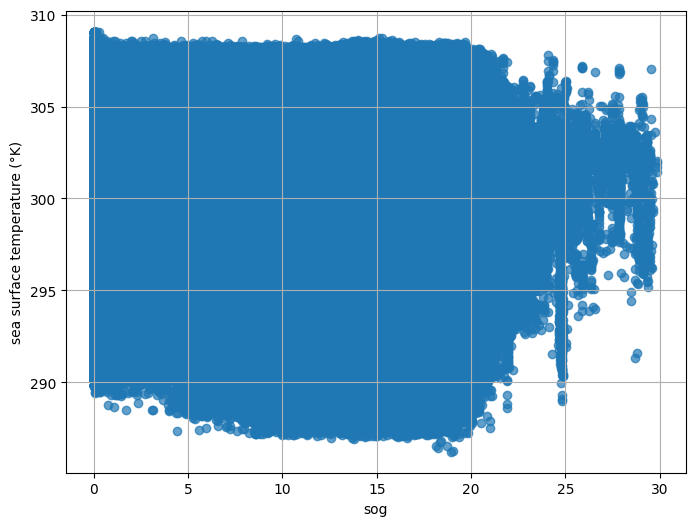

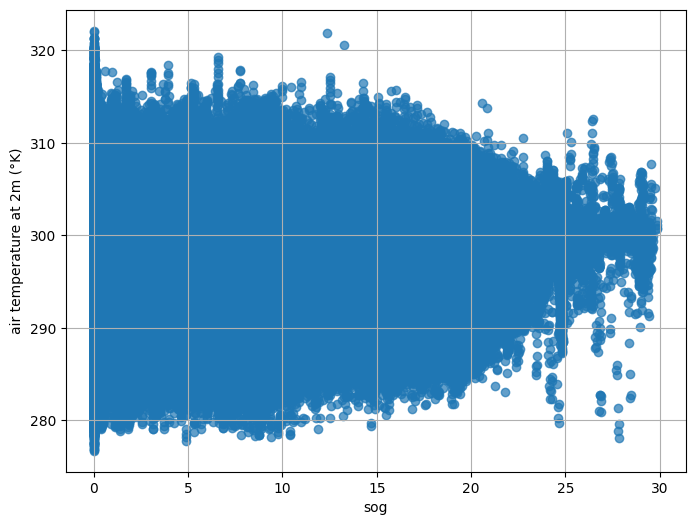

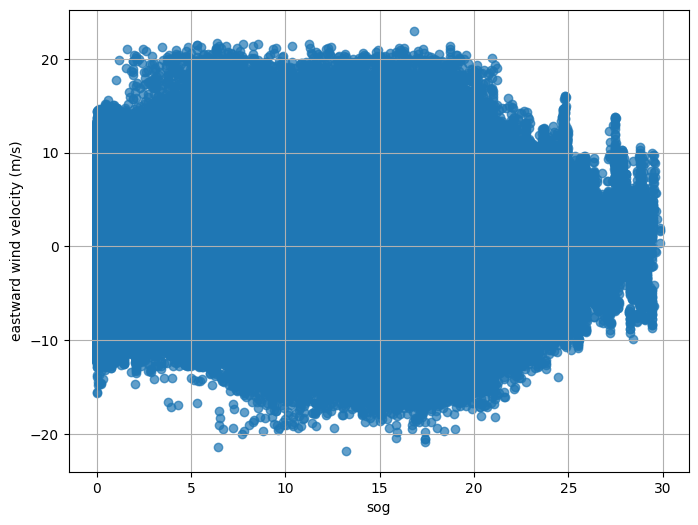

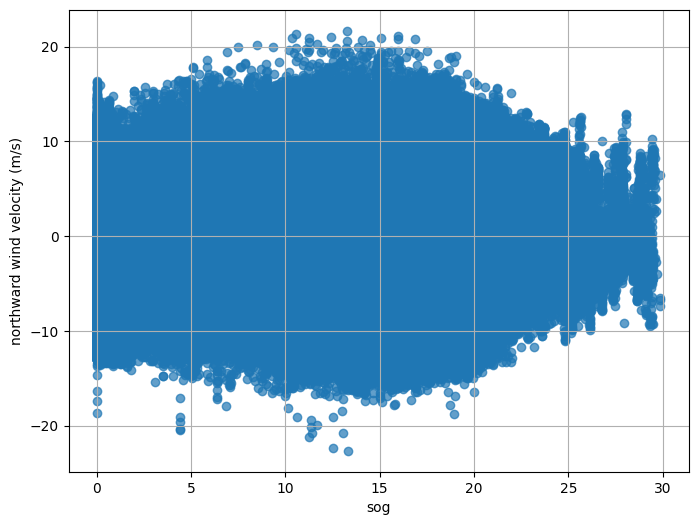

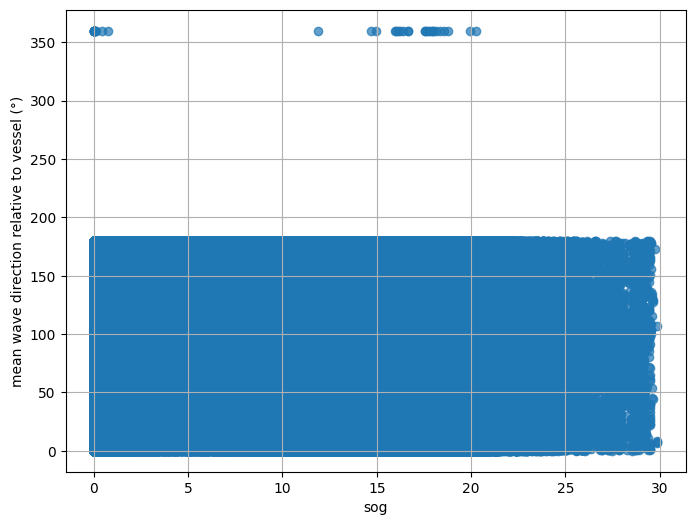

In [10]:
for second_variable in Vargood:
    scatter_plot(df, x_col='sog', y_col=second_variable,
                 color_col=None, size_col=None,
                 title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7)

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def bar_chart_superpose(df, y_col, indicator_col, title=None, xlabel=None, ylabel="Effectifs",
                        figsize=(10,6), alpha=0.6, colors=('blue', 'orange')):
    """
    Affiche deux bar charts superposés pour la répartition d'une variable selon une indicatrice (0/1)
    
    Parameters
    ----------
    df : pandas.DataFrame
        Le DataFrame contenant les données
    y_col : str
        Nom de la colonne à analyser (variable catégorielle ou discrète)
    indicator_col : str
        Nom de la colonne indicatrice (0/1)
    title : str, optional
        Titre du graphique
    xlabel : str, optional
        Label de l'axe X
    ylabel : str, optional
        Label de l'axe Y
    figsize : tuple, optional
        Taille de la figure
    alpha : float, optional
        Transparence des barres
    colors : tuple, optional
        Couleurs pour indicatrice=0 et indicatrice=1
    """

    # Comptage pour indicatrice=0 et indicatrice=1
    counts_0 = df[df[indicator_col] == 0][y_col].value_counts().sort_index()
    counts_1 = df[df[indicator_col] == 1][y_col].value_counts().sort_index()
    
    # Alignement des catégories (si certaines catégories absentes dans l’un ou l’autre)
    all_index = sorted(set(counts_0.index) | set(counts_1.index))
    counts_0 = counts_0.reindex(all_index, fill_value=0)
    counts_1 = counts_1.reindex(all_index, fill_value=0)
    
    # Création du plot
    x = np.arange(len(all_index))  # positions sur l'axe X
    width = 0.4  # largeur des barres
    
    plt.figure(figsize=figsize)
    
    # Barres superposées
    plt.bar(x - width/2, counts_0, width=width, color=colors[0], alpha=alpha, label=f'{indicator_col}=0')
    plt.bar(x + width/2, counts_1, width=width, color=colors[1], alpha=alpha, label=f'{indicator_col}=1')
    
    # Labels et titre
    plt.xticks(x, all_index, rotation=45)
    plt.xlabel(xlabel if xlabel else y_col)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
Vargood=['wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)']